# RetailPulse — EDA & Data Cleaning
### Online Retail Dataset | Zidio Development | March 2026

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats.mstats import winsorize
import os

## 2. Load Dataset

In [2]:
data = pd.read_csv(r"..\data\raw\OnlineRetail.csv", encoding='latin1')  # ADD PATH ACCORDINGLY
print(f"Shape: {data.shape}")
data.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 3. Initial Inspection

In [3]:
df = data.copy()
print(f"Rows   : {len(df):,}")
print(f"Columns: {len(df.columns)}")
print()
df.info()

Rows   : 541,909
Columns: 8

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
display(df.describe())

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## 4. Missing Value Analysis

In [5]:
def missing_summary(dataframe, name):
    miss = dataframe.isnull().sum()
    pct  = (miss / len(dataframe) * 100).round(2)
    summary = pd.DataFrame({'Missing Count': miss, 'Missing %': pct})
    summary = summary[summary['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    print(f'\n[{name}] — {len(summary)} columns with nulls')
    display(summary)

missing_summary(df, 'Original Data')


[Original Data] — 2 columns with nulls


,Missing Count,Missing %
CustomerID,135080,24.93
Description,1454,0.27


## 5. Data Cleaning

**Steps:**
1. Fill missing `CustomerID` using same-invoice lookup → remaining stay as NaN (unknown customers)
2. Remove cancelled orders (InvoiceNo starting with 'C')
3. Remove rows with Quantity ≤ 0 or UnitPrice ≤ 0
4. Parse `InvoiceDate` to datetime
5. Create `Revenue` column
6. Fix `Description` nulls using StockCode map

In [6]:
# ── Step 1: Fill CustomerID using same-invoice lookup ────────────
invoice_to_customer = (
    df.dropna(subset=['CustomerID'])
    .groupby('InvoiceNo')['CustomerID']
    .first()
)
df['CustomerID'] = df['CustomerID'].fillna(df['InvoiceNo'].map(invoice_to_customer))

# Separate unknown customers (keep for reference, exclude from analytics)
df_unknown = df[df['CustomerID'].isna()].copy()
df = df[df['CustomerID'].notna()].copy()
df['CustomerID'] = df['CustomerID'].astype(int)

print(f"Known customer rows  : {len(df):,}")
print(f"Unknown customer rows: {len(df_unknown):,}")

Known customer rows  : 406,829
Unknown customer rows: 135,080


In [7]:
# ── Step 2-4: Remove bad rows, parse dates ───────────────────────
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]   # remove cancellations
df = df[df["Quantity"]  > 0]
df = df[df["UnitPrice"] > 0]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="mixed", dayfirst=True)

# ── Step 5: Revenue column ────────────────────────────────────────
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

print(f"Clean rows      : {len(df):,}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")
print(f"Unique products : {df['StockCode'].nunique():,}")
print(f"Date range      : {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")

Clean rows      : 397,884
Unique customers: 4,338
Unique products : 3,665
Date range      : 2010-01-12 → 2011-12-10


In [8]:
# ── Step 6: Fix Description nulls using StockCode map ───────────
code_to_desc = (
    df.dropna(subset=['Description'])
    .groupby('StockCode')['Description']
    .agg(lambda x: x.mode()[0])
)
df['Description'] = df['Description'].fillna(df['StockCode'].map(code_to_desc))

manual_map = {
    'POST': 'Postage', 'DOT': 'Dotcom Postage', 'M': 'Manual Entry',
    'BANK CHARGES': 'Bank Charges', 'AMAZONFEE': 'Amazon Fee',
    'C2': 'Carriage', 'S': 'Sample', 'CRUK': 'CRUK Commission'
}
df['Description'] = df['Description'].fillna(df['StockCode'].map(manual_map))
df['Description'] = df['Description'].fillna('UNKNOWN_' + df['StockCode'].astype(str))

print(f"Description nulls remaining: {df['Description'].isnull().sum()}")
missing_summary(df, 'After Cleaning')

Description nulls remaining: 0

[After Cleaning] — 0 columns with nulls


,Missing Count,Missing %


## 6. Outlier Detection & Winsorization

**Methods used:**
- IQR (Interquartile Range) — identify fence breaches
- Z-Score — flag rows with |z| > 3
- Winsorization — cap at 5th & 95th percentile (EDA/visualization safe)
- `df_original` saved before capping for honest before/after comparison

In [9]:
# ── IQR Outliers ─────────────────────────────────────────────────
def iqr_outliers(series, label):
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f"\n IQR Outliers — {label}")
    print(f"  Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}")
    print(f"  Lower fence : {lower:.2f}")
    print(f"  Upper fence : {upper:.2f}")
    print(f"  Outlier rows: {len(outliers):,}  ({len(outliers)/len(series)*100:.1f}%)")
    return lower, upper, outliers

qty_lower,   qty_upper,   qty_out   = iqr_outliers(df["Quantity"],  "Quantity")
price_lower, price_upper, price_out = iqr_outliers(df["UnitPrice"], "UnitPrice")
rev_lower,   rev_upper,   rev_out   = iqr_outliers(df["Revenue"],   "Revenue")


 IQR Outliers — Quantity
  Q1=2.00  Q3=12.00  IQR=10.00
  Lower fence : -13.00
  Upper fence : 27.00
  Outlier rows: 25,647  (6.4%)

 IQR Outliers — UnitPrice
  Q1=1.25  Q3=3.75  IQR=2.50
  Lower fence : -2.50
  Upper fence : 7.50
  Outlier rows: 34,356  (8.6%)

 IQR Outliers — Revenue
  Q1=4.68  Q3=19.80  IQR=15.12
  Lower fence : -18.00
  Upper fence : 42.48
  Outlier rows: 31,241  (7.9%)


In [10]:
# ── Z-Score Outliers ─────────────────────────────────────────────
THRESH = 3
df["z_quantity"]  = np.abs(stats.zscore(df["Quantity"]))
df["z_unitprice"] = np.abs(stats.zscore(df["UnitPrice"]))
df["z_revenue"]   = np.abs(stats.zscore(df["Revenue"]))

z_qty_out   = df[df["z_quantity"]  > THRESH]
z_price_out = df[df["z_unitprice"] > THRESH]
z_rev_out   = df[df["z_revenue"]   > THRESH]

print(f"Z-Score Outliers (|z| > {THRESH})")
print(f"  Quantity  : {len(z_qty_out):,} rows")
print(f"  UnitPrice : {len(z_price_out):,} rows")
print(f"  Revenue   : {len(z_rev_out):,} rows")

Z-Score Outliers (|z| > 3)
  Quantity  : 388 rows
  UnitPrice : 221 rows
  Revenue   : 344 rows


In [11]:
# ── Winsorization (cap at p5–p95) ────────────────────────────────
# Save original BEFORE capping for honest before/after charts
df_original = df[["Quantity", "UnitPrice", "Revenue"]].copy()

LOWER_PCT  = 0.05
UPPER_PCT  = 0.05
cols_to_cap = ["Quantity", "UnitPrice", "Revenue"]

for col in cols_to_cap:
    p05 = df[col].quantile(LOWER_PCT)
    p95 = df[col].quantile(1 - UPPER_PCT)
    df[col] = df[col].clip(lower=p05, upper=p95)
    print(f"\n── {col}")
    print(f"  Before — min: {df_original[col].min():.2f}  max: {df_original[col].max():.2f}")
    print(f"  After  — min: {df[col].min():.2f}  max: {df[col].max():.2f}")

# Recalculate Revenue from capped Quantity & UnitPrice
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Drop z-score helper columns
df.drop(columns=["z_quantity", "z_unitprice", "z_revenue"], inplace=True, errors="ignore")

print(f"\nFinal rows: {len(df):,}")


── Quantity
  Before — min: 1.00  max: 80995.00
  After  — min: 1.00  max: 36.00

── UnitPrice
  Before — min: 0.00  max: 8142.75
  After  — min: 0.42  max: 8.50

── Revenue
  Before — min: 0.00  max: 168469.60
  After  — min: 1.25  max: 67.50

Final rows: 397,884


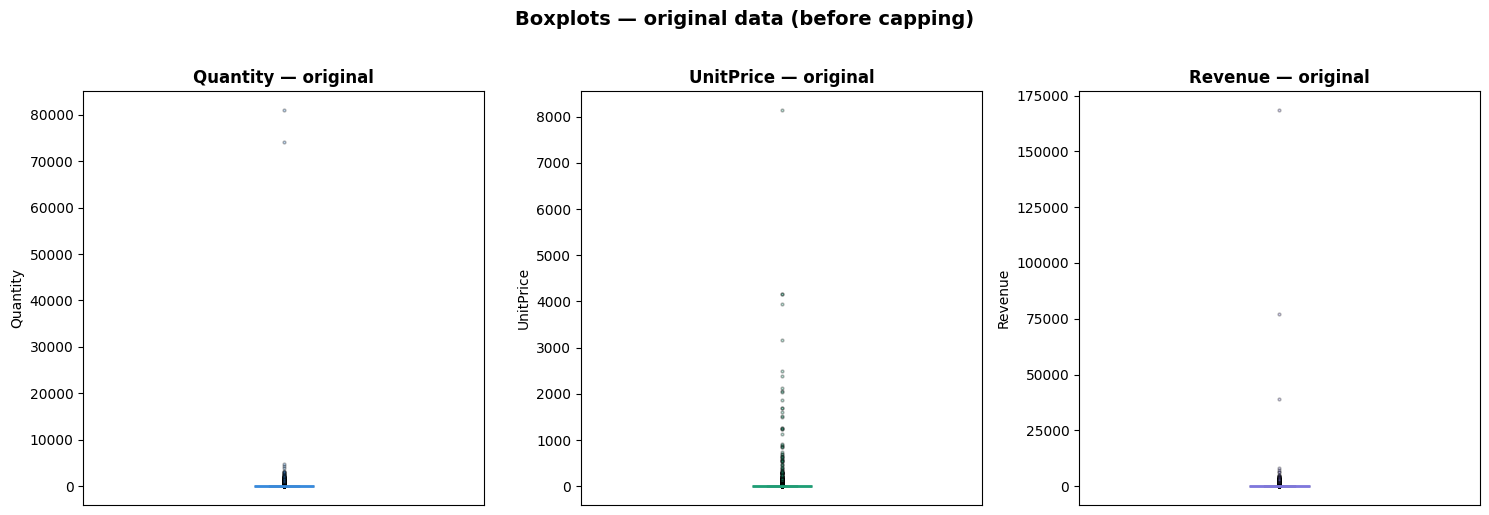

In [12]:
# ── Boxplot: Original data ────────────────────────────────────────
cols_plot  = ["Quantity", "UnitPrice", "Revenue"]
colors     = ["#378ADD", "#1D9E75", "#7F77DD"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, color in zip(axes, cols_plot, colors):
    ax.boxplot(
        df_original[col], vert=True, patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.4),
        medianprops=dict(color=color, linewidth=2),
        flierprops=dict(marker="o", markersize=2, markerfacecolor=color, alpha=0.3)
    )
    ax.set_title(f"{col} — original", fontsize=12, fontweight="bold")
    ax.set_ylabel(col)
    ax.set_xticks([])
plt.suptitle("Boxplots — original data (before capping)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

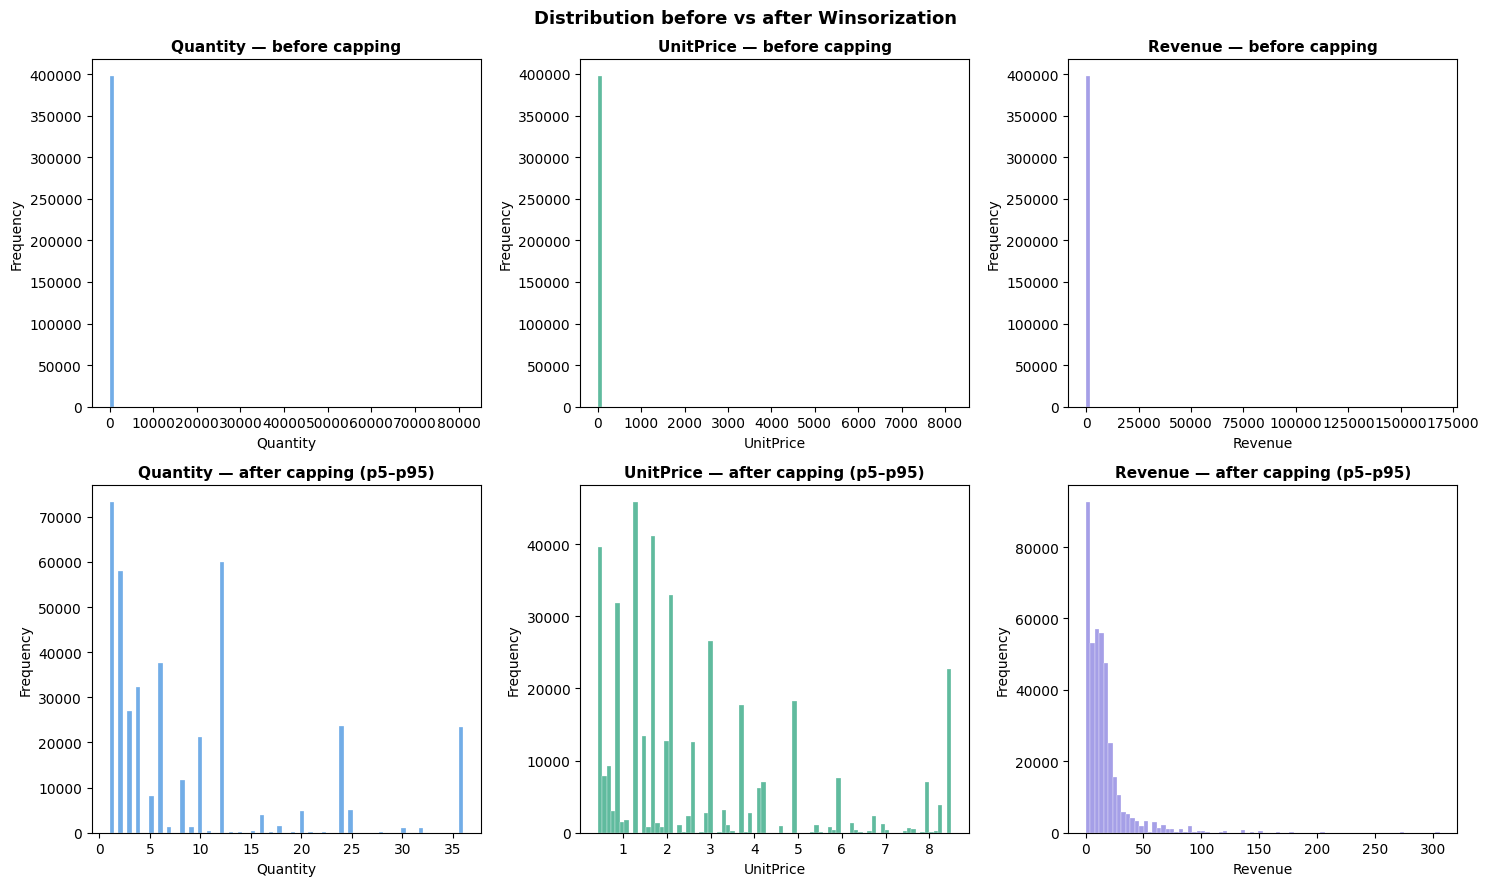

In [13]:
# ── Histogram: Before vs After Winsorization ─────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i, (col, color) in enumerate(zip(cols_plot, colors)):
    axes[0][i].hist(df_original[col], bins=80, color=color, alpha=0.7, edgecolor="white", linewidth=0.3)
    axes[0][i].set_title(f"{col} — before capping", fontsize=11, fontweight="bold")
    axes[0][i].set_xlabel(col); axes[0][i].set_ylabel("Frequency")

    axes[1][i].hist(df[col], bins=80, color=color, alpha=0.7, edgecolor="white", linewidth=0.3)
    axes[1][i].set_title(f"{col} — after capping (p5–p95)", fontsize=11, fontweight="bold")
    axes[1][i].set_xlabel(col); axes[1][i].set_ylabel("Frequency")

plt.suptitle("Distribution before vs after Winsorization", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

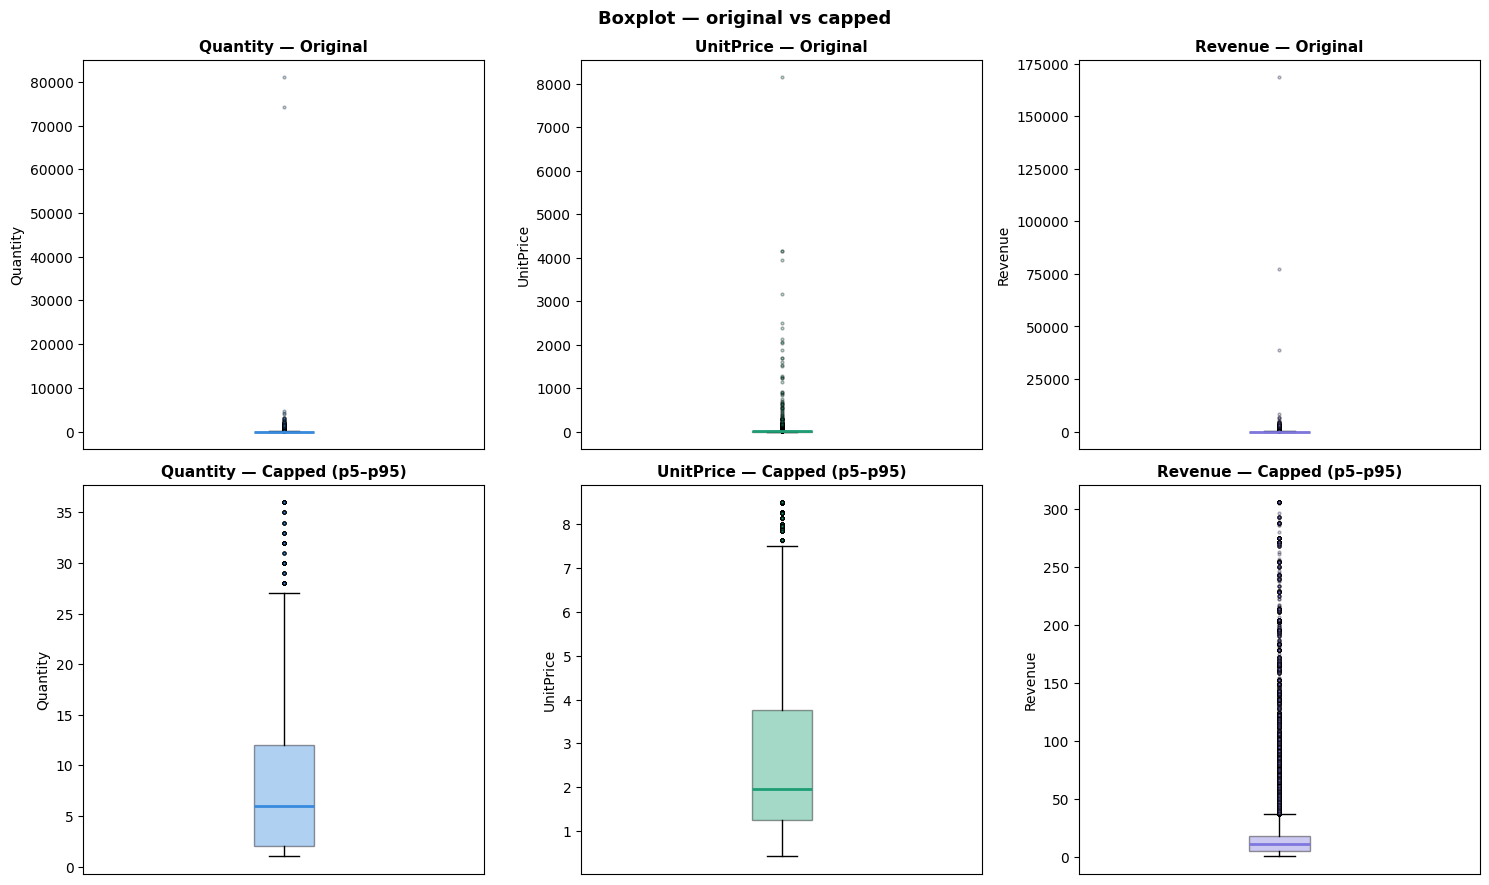

In [14]:
# ── Boxplot: Original vs Capped side-by-side ─────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i, (col, color) in enumerate(zip(cols_plot, colors)):
    for row, (data, title) in enumerate([(df_original[col], "Original"), (df[col], "Capped (p5–p95)")]):
        axes[row][i].boxplot(
            data, vert=True, patch_artist=True,
            boxprops=dict(facecolor=color, alpha=0.4),
            medianprops=dict(color=color, linewidth=2),
            flierprops=dict(marker="o", markersize=2, markerfacecolor=color, alpha=0.3)
        )
        axes[row][i].set_title(f"{col} — {title}", fontsize=11, fontweight="bold")
        axes[row][i].set_ylabel(col)
        axes[row][i].set_xticks([])
plt.suptitle("Boxplot — original vs capped", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [15]:
# ── Outlier Summary ──────────────────────────────────────────────
z_total = len(z_qty_out) + len(z_price_out) + len(z_rev_out)
print("OUTLIER SUMMARY")
print(f"  IQR outliers — Quantity  : {len(qty_out):,}  ({len(qty_out)/len(df)*100:.1f}%)")
print(f"  IQR outliers — UnitPrice : {len(price_out):,}  ({len(price_out)/len(df)*100:.1f}%)")
print(f"  IQR outliers — Revenue   : {len(rev_out):,}  ({len(rev_out)/len(df)*100:.1f}%)")
print(f"  Z-score outliers (any)   : {z_total:,}")
print(f"  Capping applied at       : 5th & 95th percentile")

OUTLIER SUMMARY
  IQR outliers — Quantity  : 25,647  (6.4%)
  IQR outliers — UnitPrice : 34,356  (8.6%)
  IQR outliers — Revenue   : 31,241  (7.9%)
  Z-score outliers (any)   : 953
  Capping applied at       : 5th & 95th percentile


## 7. Feature Engineering

**Time-based features:** Year, Month, Quarter, Week, DayOfWeek, Hour, Is_Weekend

**Customer-level features:** total_orders, total_items, total_spend, avg_order_value,
unique_products, days_since_last_purchase, customer_lifespan_days

> Built on fully cleaned & capped `df` — used as input to RFM + segmentation notebook.

In [16]:
# ── Time-based features ──────────────────────────────────────────
df['Year']       = df['InvoiceDate'].dt.year
df['Month']      = df['InvoiceDate'].dt.month
df['Quarter']    = df['InvoiceDate'].dt.quarter
df['Week']       = df['InvoiceDate'].dt.isocalendar().week.astype(int)
df['DayOfWeek']  = df['InvoiceDate'].dt.dayofweek   # 0 = Monday
df['Hour']       = df['InvoiceDate'].dt.hour
df['Is_Weekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)


print("Time features added:")
print(df[['InvoiceDate','Year','Month','Quarter','DayOfWeek','Hour','Is_Weekend']].head(3))

Time features added:
          InvoiceDate  Year  Month  Quarter  DayOfWeek  Hour  Is_Weekend
0 2010-01-12 08:26:00  2010      1        1          1     8           0
1 2010-01-12 08:26:00  2010      1        1          1     8           0
2 2010-01-12 08:26:00  2010      1        1          1     8           0


In [17]:
# ── Customer-level aggregation ───────────────────────────────────
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

customer_features = (
    df.groupby('CustomerID')
    .agg(
        total_orders    = ('InvoiceNo',   'nunique'),
        total_items     = ('Quantity',    'sum'),
        total_spend     = ('Revenue',     'sum'),
        avg_order_value = ('Revenue',     'mean'),
        unique_products = ('StockCode',   'nunique'),
        first_purchase  = ('InvoiceDate', 'min'),
        last_purchase   = ('InvoiceDate', 'max'),
    )
    .reset_index()
)

customer_features['days_since_last'] = (
    snapshot_date - customer_features['last_purchase']
).dt.days

customer_features['customer_lifespan_days'] = (
    customer_features['last_purchase'] - customer_features['first_purchase']
).dt.days

print(f"Customer feature table: {customer_features.shape}")
display(customer_features.head())

Customer feature table: (4338, 10)


,CustomerID,total_orders,total_items,total_spend,avg_order_value,unique_products,first_purchase,last_purchase,days_since_last,customer_lifespan_days
0,12346,1,36,37.44,37.440000,1,2011-01-18 10:01:00,2011-01-18 10:01:00,327,0
1,12347,7,2242,4015.21,22.061593,103,2010-07-12 14:57:00,2011-10-31 12:25:00,41,475
2,12348,4,905,732.62,23.632903,22,2010-12-16 19:09:00,2011-09-25 13:13:00,77,282
3,12349,1,631,1389.15,19.029452,73,2011-11-21 09:51:00,2011-11-21 09:51:00,20,0
4,12350,1,197,302.90,17.817647,17,2011-02-02 16:01:00,2011-02-02 16:01:00,312,0


## 8. Exploratory Data Analysis (EDA)

**8 analyses:**
1. Customer visit frequency
2. Top 15 products by quantity
3. Product demand by country + heatmap
4. Customer spend distribution
5. Monthly revenue trend
6. Revenue heatmap — day of week × hour
7. Repeat vs one-time buyers
8. Basket size distribution

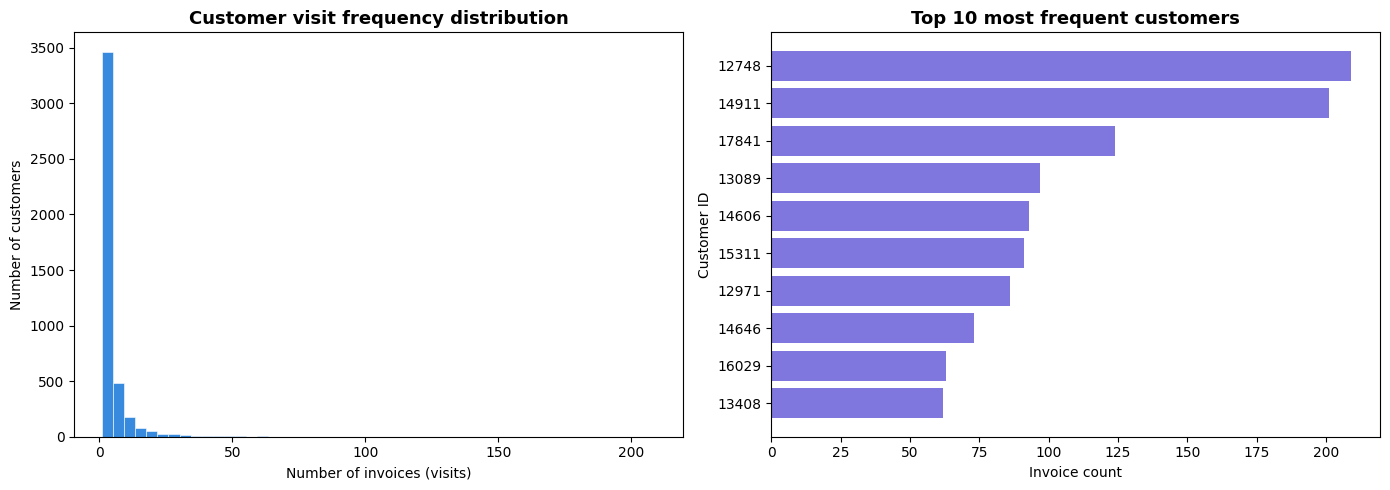

In [18]:
# ── EDA 1 — Customer visit frequency ─────────────────────────────
visits_per_customer = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .reset_index()
    .rename(columns={"InvoiceNo": "visit_count"})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(visits_per_customer["visit_count"], bins=50,
             color="#378ADD", edgecolor="white", linewidth=0.4)
axes[0].set_title("Customer visit frequency distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of invoices (visits)")
axes[0].set_ylabel("Number of customers")

top_customers = visits_per_customer.nlargest(10, "visit_count")
axes[1].barh(top_customers["CustomerID"].astype(str), top_customers["visit_count"], color="#7F77DD")
axes[1].invert_yaxis()
axes[1].set_title("Top 10 most frequent customers", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Invoice count")
axes[1].set_ylabel("Customer ID")
plt.tight_layout(); plt.show()

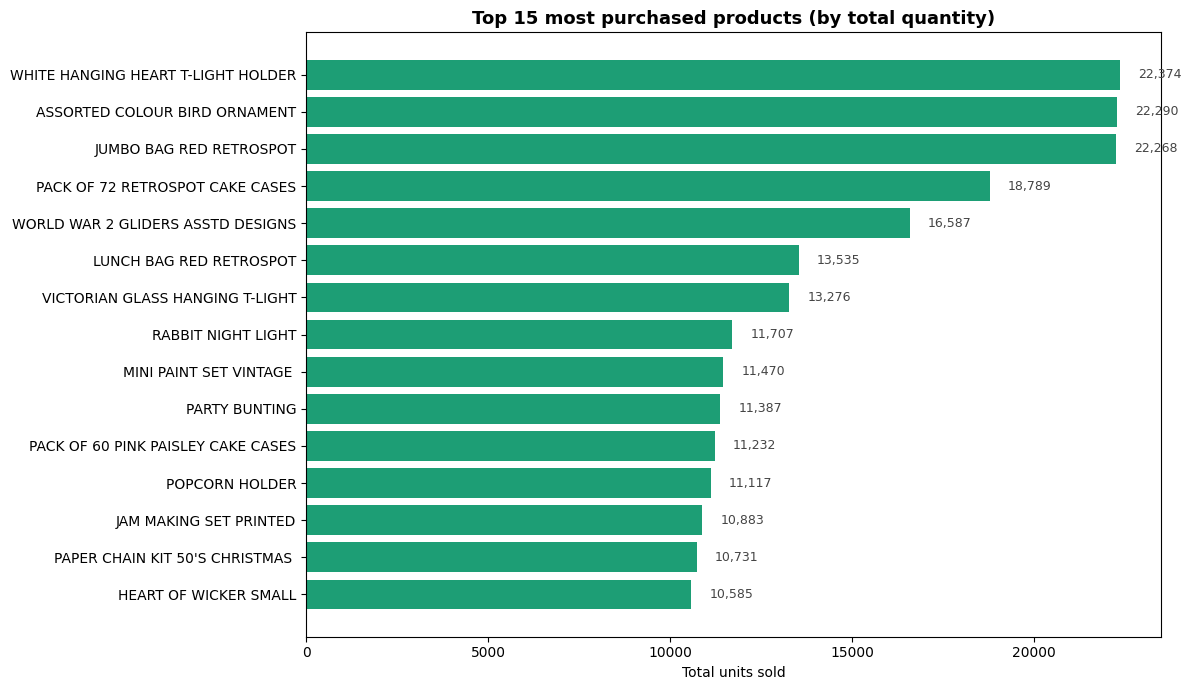

In [19]:
# ── EDA 2 — Top 15 products by quantity ──────────────────────────
top_products = (
    df.groupby("Description")["Quantity"]
    .sum().nlargest(15).sort_values().reset_index()
)
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_products["Description"], top_products["Quantity"], color="#1D9E75")
ax.set_title("Top 15 most purchased products (by total quantity)", fontsize=13, fontweight="bold")
ax.set_xlabel("Total units sold")
for bar in bars:
    w = bar.get_width()
    ax.text(w + 500, bar.get_y() + bar.get_height() / 2,
            f"{int(w):,}", va="center", fontsize=9, color="#444")
plt.tight_layout(); plt.show()

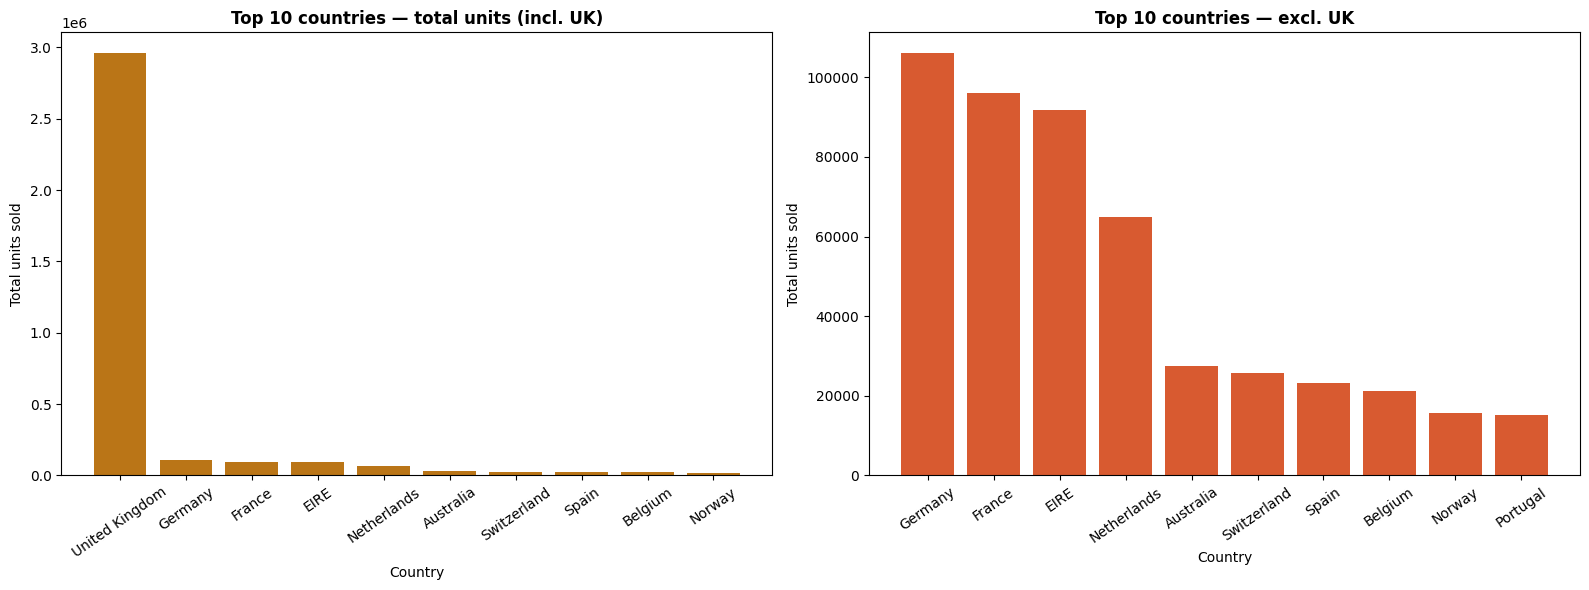

In [20]:
# ── EDA 3 — Product demand by country ────────────────────────────
units_by_country = (
    df.groupby("Country")["Quantity"].sum()
    .sort_values(ascending=False).reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].bar(units_by_country.head(10)["Country"],
            units_by_country.head(10)["Quantity"], color="#BA7517")
axes[0].set_title("Top 10 countries — total units (incl. UK)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Country"); axes[0].set_ylabel("Total units sold")
axes[0].tick_params(axis="x", rotation=35)

no_uk = units_by_country[units_by_country["Country"] != "United Kingdom"].head(10)
axes[1].bar(no_uk["Country"], no_uk["Quantity"], color="#D85A30")
axes[1].set_title("Top 10 countries — excl. UK", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Country"); axes[1].set_ylabel("Total units sold")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout(); plt.show()

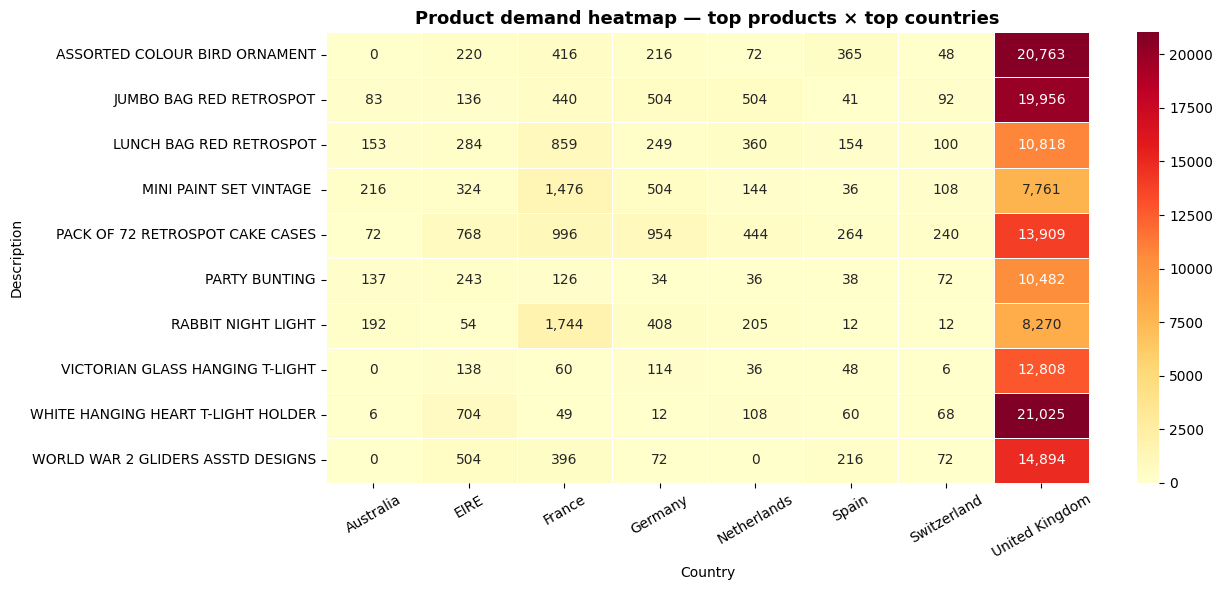

In [21]:
# ── EDA 3b — Heatmap: top 10 products × top 8 countries ─────────
top8_countries = units_by_country.head(8)["Country"].tolist()
top10_prods    = df.groupby("Description")["Quantity"].sum().nlargest(10).index.tolist()
pivot = (
    df[df["Country"].isin(top8_countries) & df["Description"].isin(top10_prods)]
    .groupby(["Description","Country"])["Quantity"].sum().unstack(fill_value=0)
)
fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot, annot=True, fmt=",", cmap="YlOrRd", linewidths=0.4, ax=ax)
ax.set_title("Product demand heatmap — top products × top countries",
             fontsize=13, fontweight="bold")
plt.xticks(rotation=30); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

── Spend summary ──────────────────────────
Total revenue : £6,408,978
Mean spend    : £1,477
Median spend  : £609
Top spender   : Customer 14911.0 — £120,647


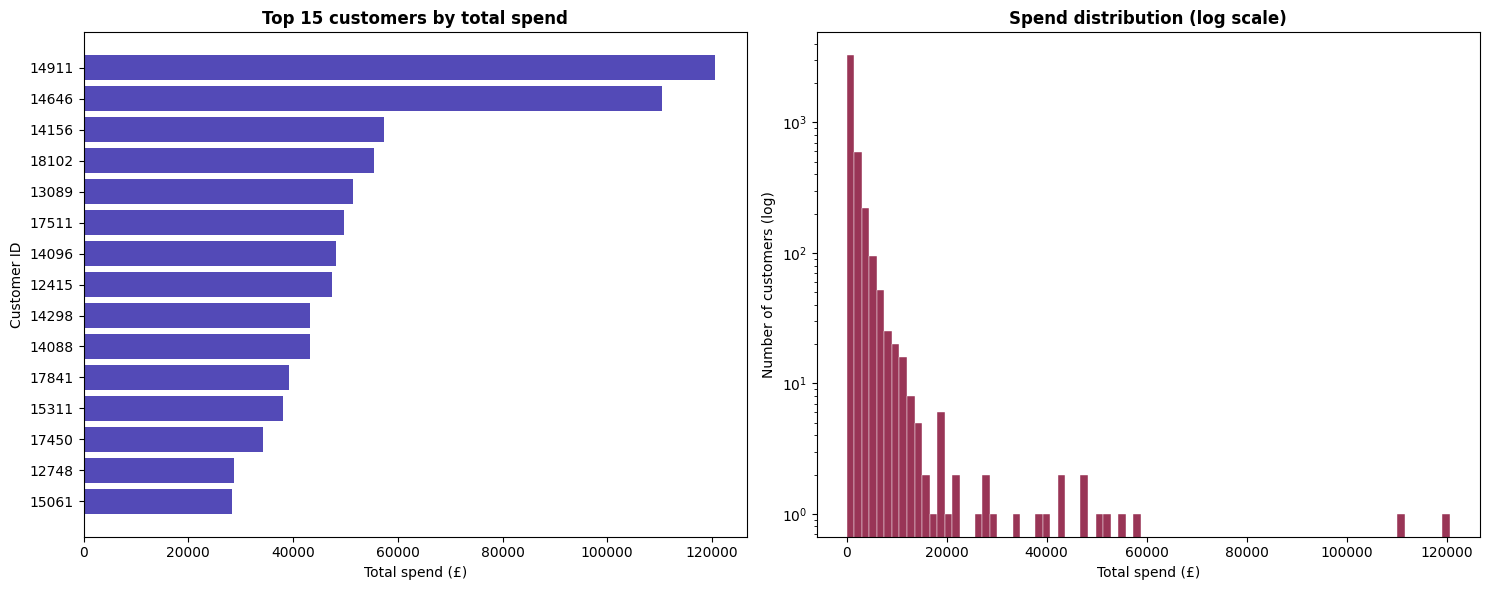

In [22]:
# ── EDA 4 — Customer spend distribution ──────────────────────────
spend_per_customer = (
    df.groupby("CustomerID")["Revenue"].sum()
    .reset_index().rename(columns={"Revenue": "total_spend"})
    .sort_values("total_spend", ascending=False)
)
print("── Spend summary ──────────────────────────")
print(f"Total revenue : £{spend_per_customer['total_spend'].sum():,.0f}")
print(f"Mean spend    : £{spend_per_customer['total_spend'].mean():,.0f}")
print(f"Median spend  : £{spend_per_customer['total_spend'].median():,.0f}")
print(f"Top spender   : Customer {spend_per_customer.iloc[0]['CustomerID']}"
      f" — £{spend_per_customer.iloc[0]['total_spend']:,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
top15 = spend_per_customer.head(15).copy()
top15["CustomerID"] = top15["CustomerID"].astype(str)
axes[0].barh(top15["CustomerID"], top15["total_spend"], color="#534AB7")
axes[0].invert_yaxis()
axes[0].set_title("Top 15 customers by total spend", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Total spend (£)"); axes[0].set_ylabel("Customer ID")

axes[1].hist(spend_per_customer["total_spend"], bins=80,
             color="#993556", edgecolor="white", linewidth=0.3)
axes[1].set_yscale("log")
axes[1].set_title("Spend distribution (log scale)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Total spend (£)"); axes[1].set_ylabel("Number of customers (log)")
plt.tight_layout(); plt.show()

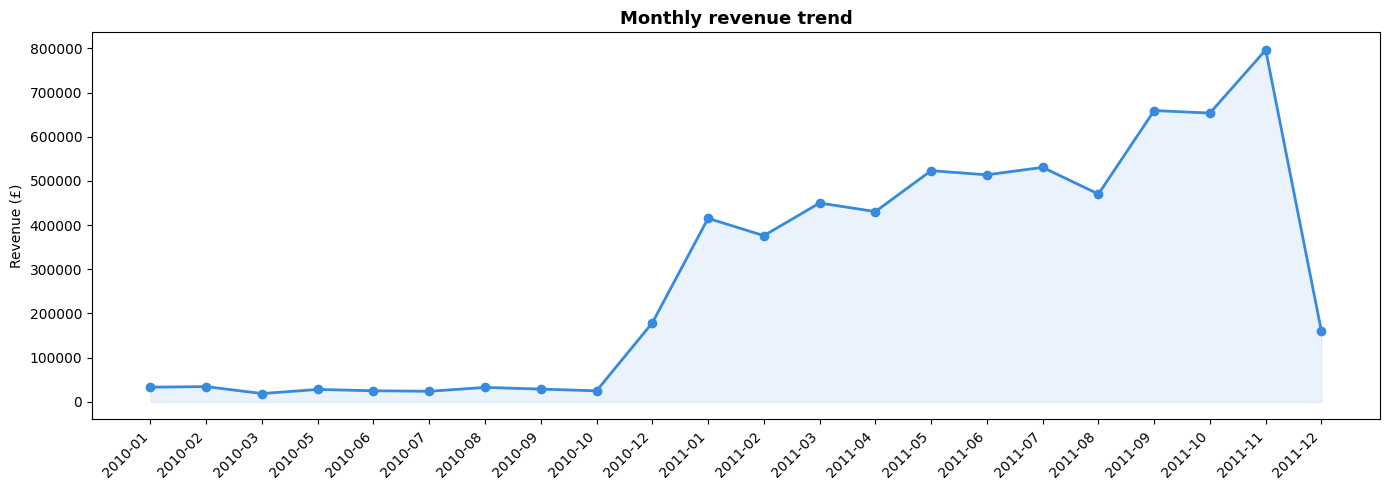

In [23]:
# ── EDA 5 — Monthly revenue trend ────────────────────────────────
monthly_rev = (
    df.groupby(df['InvoiceDate'].dt.to_period('M'))['Revenue']
    .sum().reset_index()
)
monthly_rev['InvoiceDate'] = monthly_rev['InvoiceDate'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_rev['InvoiceDate'], monthly_rev['Revenue'],
        marker='o', color='#378ADD', linewidth=2)
ax.fill_between(range(len(monthly_rev)), monthly_rev['Revenue'],
                alpha=0.1, color='#378ADD')
ax.set_xticks(range(len(monthly_rev)))
ax.set_xticklabels(monthly_rev['InvoiceDate'], rotation=45, ha='right')
ax.set_title('Monthly revenue trend', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue (£)')
plt.tight_layout(); plt.show()

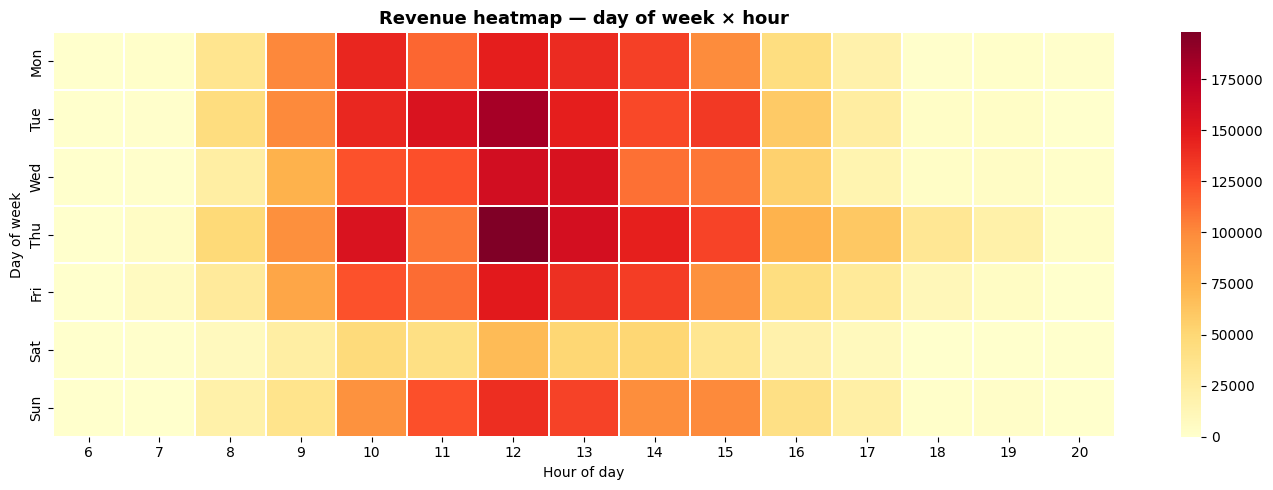

In [24]:
# ── EDA 6 — Revenue heatmap: day of week × hour ──────────────────
pivot_time = (
    df.groupby(['DayOfWeek', 'Hour'])['Revenue']
    .sum().unstack(fill_value=0)
)
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
pivot_time.index = day_labels[:len(pivot_time)]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_time, cmap='YlOrRd', ax=ax, linewidths=0.3, annot=False)
ax.set_title('Revenue heatmap — day of week × hour', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of day'); ax.set_ylabel('Day of week')
plt.tight_layout(); plt.show()

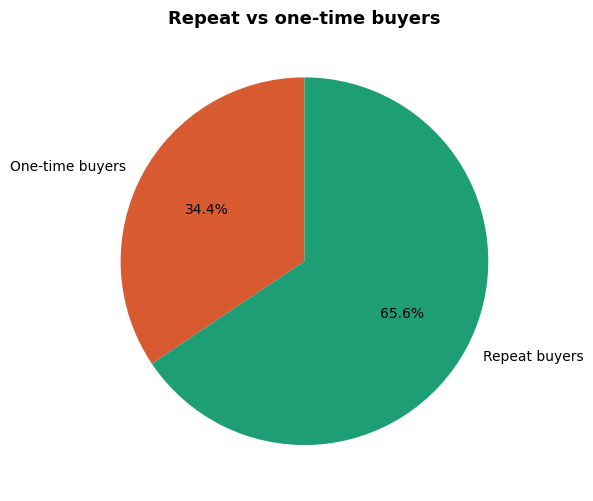

One-time buyers : 1,493  |  Repeat buyers : 2,845


In [25]:
# ── EDA 7 — Repeat vs one-time buyers ────────────────────────────
order_counts = df.groupby('CustomerID')['InvoiceNo'].nunique()
one_time = (order_counts == 1).sum()
repeat   = (order_counts  > 1).sum()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie([one_time, repeat],
       labels=['One-time buyers', 'Repeat buyers'],
       autopct='%1.1f%%', colors=['#D85A30', '#1D9E75'], startangle=90)
ax.set_title('Repeat vs one-time buyers', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"One-time buyers : {one_time:,}  |  Repeat buyers : {repeat:,}")

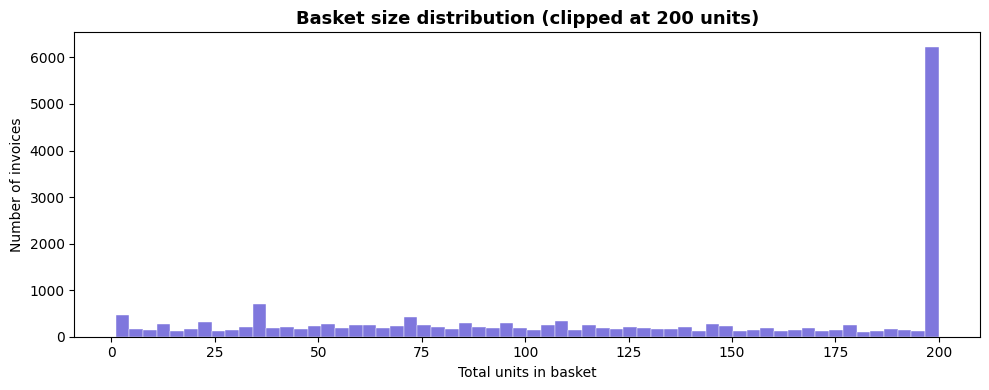

Median basket : 134 units
Mean basket   : 190.4 units


In [26]:
# ── EDA 8 — Basket size distribution ─────────────────────────────
basket = df.groupby('InvoiceNo')['Quantity'].sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(basket.clip(upper=200), bins=60,
        color='#7F77DD', edgecolor='white', linewidth=0.3)
ax.set_title('Basket size distribution (clipped at 200 units)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Total units in basket')
ax.set_ylabel('Number of invoices')
plt.tight_layout(); plt.show()
print(f"Median basket : {basket.median():.0f} units")
print(f"Mean basket   : {basket.mean():.1f} units")

## 9. Correlation Heatmap

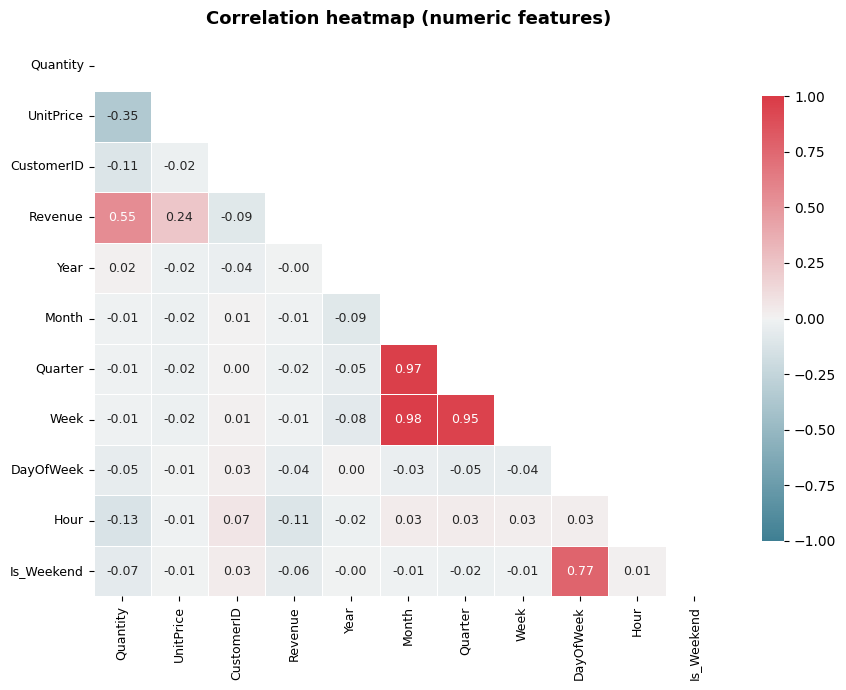

In [27]:
fig, ax = plt.subplots(figsize=(9, 7))
num_df = df.select_dtypes(include=np.number)
corr   = num_df.corr()
mask   = np.triu(np.ones_like(corr, dtype=bool))
cmap   = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(
    corr, ax=ax, mask=mask, annot=True, fmt=".2f",
    cmap=cmap, center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    annot_kws={"size": 9}, cbar_kws={"shrink": 0.8}
)
ax.set_title("Correlation heatmap (numeric features)", fontsize=13, fontweight="bold", pad=12)
ax.tick_params(labelsize=9)
plt.tight_layout(); plt.show()

## 10. Save Cleaned Data

In [28]:
import os
os.makedirs(r"..\data\processed", exist_ok=True)

# Main cleaned + featured transaction dataset
df.to_csv(r"..\data\processed\cleaned_retail.csv", index=False)

# Customer-level feature table → input for segmentation & churn notebooks
customer_features.to_csv(r"..\data\processed\customer_features.csv", index=False)

print("Files saved to data/processed/")
print(f"  cleaned_retail.csv    — {len(df):,} rows, {df.shape[1]} cols")
print(f"  customer_features.csv — {len(customer_features):,} customers, {customer_features.shape[1]} cols")

Files saved to data/processed/
  cleaned_retail.csv    — 397,884 rows, 16 cols
  customer_features.csv — 4,338 customers, 10 cols
